<a href="https://colab.research.google.com/github/kithik7/Advanced_Stats_4_Neurowissenschaften/blob/Stats_Lectures_2026/Advanced_Statistics_L07_Bayesian_reasoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
 <p>116 Advanced Statistics</p>
 <h1></h1>
 <h1>Lecture 07: Bayesian reasoning </h1>
 <p>----</p>
 <p>Prof. Jochen Braun Ph.D.</p>
 <p>Institute of Biology</p>
 <p>Otto-von-Guericke University Magdeburg</p>
 <p>----</p>
 <p>Textbook:</p>
 <p> B Efron & T Hastie (2016) Computer Age Statistical Inference, </p>
 <p> Cambridge University Press.</p>
</center>

# **Abstract:**

This lecture reviews Bayesian reasoning in the context of statistics.

After recalling how odds are lengthened or shortened by the **Bayes factor**, we provide some examples of **empirical Bayesian** reasoning.

Next we introduce the **Bayesian Information Criterion (BIC)** for comparing fitted models, exemplifying both linear and generalized linear models.

Finally, we tackles the problem of **false discovery rates**, which arises in modern large-scale analyses that test thousands of hypotheses concurrently.
Fortunately, the issue has an elegant Bayesian solutions.





# **Overview:**


**1. Bayes Factor**

**2. Empirical Bayesian reasoning**

**3. Bayesian Information Criterion (BIC)**

**4. False discovery corrections**





# **1. Bayes factor**

Let's refresh our Bayesian background and review **priors**, **posteriors**, and the **Bayes factor** for additional observations that can either lengthen or shorten the odds.

<br>

We start with a famous example from medical psychology and retrace the brilliant exposition by youtuber [Grant Sanderson (3blue1brown)](https://www.3blue1brown.com/lessons/better-bayes). Specifically, we consider the incidence of breast cancer in middle-aged women and the correct interpretation of screening tests.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_bayes_factor_one.png" width="600">

<br>

The indicence of breast cancer in 50 year-old women **without symptoms** is approximately 1%, or ten women in one thousand. Accordingly, the **prior odds** that any member of this population does or does not have cancer are

<br>

$$
\mathrm{Prior}\,\,\mathrm{Odds} = \frac{P(\mathrm{cancer})}{P(\mathrm{no \,\, cancer})} = \frac{1}{99}
$$



# Sensitivity and specificity of screening

The **sensitivity** and the **false negative rate** (FNR) of a screening test are defined as conditional probabilities for the **cancer-positive** subpopulation.

<br>

$$
\mathrm{Sensitivity} = P(+|\mathrm{cancer}) = \frac{9}{10}=90\%, \qquad\qquad \mathrm{FNR} = P(-|\mathrm{cancer})= \frac{1}{10}=10\%
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_bayes_factor_two.png" width="600">

<br>

In contrast, the **specificity** and the **false positive rate** (FPR) of a screening test are defined as conditional probabilities for the **cancer-negative** subpopulation.

<br>

$$
\mathrm{Specificity} = P(-|\mathrm{no\,\,cancer})=\frac{901}{990}\approx 91\%, \qquad\qquad \mathrm{FPR} = P(+|\mathrm{no\,\,cancer})=\frac{89}{990} \approx 9\%
$$

# Interpreting a screening result

So how should we interpret the result of a screening test?

<br>

The **posterior odds** are defined as the ratio of conditional probabilities, times the ratio of **prior odds**.

<br>

For a **positive** test, we find

$$
\mathrm{Posterior}\,\,\mathrm{Odds} \equiv \frac{P(\mathrm{cancer}|+)}{P(\mathrm{no}\,\,\mathrm{cancer}|+)}= \frac{P(+|\mathrm{cancer})}{P(+|\mathrm{no}\,\,\mathrm{cancer})} \cdot \frac{P(\mathrm{cancer})}{P(\mathrm{no \,\, cancer})} = \frac{90\%}{9\%} \cdot \frac{1}{99} \approx \frac{1}{10}
$$

In other words, a positive tests shortens our odds from 1/99 before the test to 1/10 after the test.

<br>

For a **negative** test, we find

$$
\mathrm{Posterior}\,\,\mathrm{Odds} \equiv \frac{P(\mathrm{cancer}|-)}{P(\mathrm{no}\,\,\mathrm{cancer}|-)} = \frac{P(-|\mathrm{cancer})}{P(-|\mathrm{no}\,\,\mathrm{cancer})} \cdot \frac{P(\mathrm{cancer})}{P(\mathrm{no \,\, cancer})} = \frac{10\%}{91\%} \cdot \frac{1}{99} \approx \frac{1}{900}
$$

so that a negative tests lengthens our odds from 1/99 before the test to 1/900 after the test.

# Probability tables

The above equates the ratios of conditional probabilities (for the **same condition**!) to the ratios of joint probabilities. Why should this be case?

<br>

As always, the comprehensive picture is provided by the probability tables for conditional and joint probabilities.

<br>

In our example, the **conditional probabilities of test results** were given:

$$\begin{array}{|cc|}
\hline
P(\mathrm{cancer}) & P(\mathrm{no \,\,cancer})   \\
0.01 & 0.99 & \\
\hline
P(\mathrm{+|cancer}) & P(+|\mathrm{no \,\,cancer})  \\
0.9 & 0.09 & \\
P(\mathrm{-|cancer}) & P(-|\mathrm{no \,\,cancer})   \\
0.1 & 0.91 & \\
\hline
\end{array}$$

<br>

Multiplying conditionals with priors (columnwise), we obtain the **joint probabilities** and the **marginal probabilities** (rowwise).

$$\begin{array}{|cc|c|}
\hline
P(\mathrm{cancer}) & P(\mathrm{no \,\,cancer})  &  \\
0.01 & 0.99 & \\
\hline
P(\mathrm{+,cancer}) & P(+,\mathrm{no \,\,cancer})  &  P(+)\\
0.009 & 0.0891 & 0.0981\\
P(\mathrm{-,cancer}) & P(-,\mathrm{no \,\,cancer})  & P(-) \\
0.001 & 0.9009 & 0.9019\\
\hline
\end{array}$$

<br>

Dividing joints by marginals (rowwise), we obtain the **conditional probabilities of cancer:**

$$\begin{array}{|cc|c|}
\hline
P(\mathrm{cancer}) & P(\mathrm{no \,\,cancer})  &  \\
0.01 & 0.99 & \\
\hline
P(\mathrm{cancer|+}) & P(\mathrm{no \,\,cancer}|+)  &  P(+)\\
0.0917 & 0.9083 & 0.0981\\
P(\mathrm{cancer|-}) & P(\mathrm{no \,\,cancer}|-)  & P(-) \\
0.0011 & 0.9989 & 0.9019\\
\hline
\end{array}$$

<br>

Now we can understand the equivalence of the ratios of conditional probabilities (same condition!) and joint probabilities:

<br>

$$
\frac{P(\mathrm{cancer}|+)\cdot P(+)}{P(\mathrm{no}\,\,\mathrm{cancer}|+)\cdot P(+)}= \frac{P(\mathrm{cancer},+)}{P(\mathrm{no}\,\,\mathrm{cancer},+)},
\qquad\qquad
\frac{P(\mathrm{cancer}|-)\cdot P(-)}{P(\mathrm{no}\,\,\mathrm{cancer}|-)\cdot P(-)}= \frac{P(\mathrm{cancer},-)}{P(\mathrm{no}\,\,\mathrm{cancer},-)}
$$

<br>

$$
\frac{P(+|\mathrm{cancer})\cdot P(\mathrm{cancer})}{P(-|\mathrm{cancer})\cdot P(\mathrm{cancer})}= \frac{P(+,\mathrm{cancer})}{P(-,\mathrm{cancer})},
\qquad\qquad
\frac{P(+|\mathrm{no\,\,cancer})\cdot P(\mathrm{no\,\,cancer})}{P(-|\mathrm{no\,\,cancer)}\cdot P(\mathrm{no\,\,cancer})}= \frac{P(+,\mathrm{no\,\,cancer})}{P(-,\mathrm{no}\,\,\mathrm{cancer})}
$$

# The twins of the physicist

Another example of Bayesian reasoning is the following story: thanks to sonograms, a physicist found out she was going to have twin boys. “What is the probability my twins will be *Identical*, rather than *Fraternal*?” she asked. The doctor answered that one-third of twin births were *Identicals*, and two-thirds *Fraternals*, so prior probabilites of 1/3 and 2/3, respectively.

<br>

In addition, we know from the sonogram that the two children will be of the same sex (boys or girls is immaterial here). The crucial background fact is that *Identical* twins are always same-sex while *Fraternals* have probability 0.5 of having the same or different sex. In other words, the conditional probabilities of same sex, given *Identical* or *Fraternal* twins, are 1 and 1/2, respectively.

<br>

Collecting this information in standard notation, we have

$$
\pi_\mathit{frat} = 2/3, \qquad \pi_\mathit{ident} = 1/3
$$

$$
\mathrm{Pr}(\mathrm{samesex}|\mathrm{frat}) = 1/2, \qquad  \mathrm{Pr}(\mathrm{samesex}|\mathrm{ident}) = 1
$$

<br>

Combining this into Bayes fractions, we have

$$
\frac{\mathrm{Pr}(\mathrm{frat}|\mathrm{samesex})}{\mathrm{Pr}(\mathrm{ident}|\mathrm{samesex})} = \frac{\mathrm{Pr}(\mathrm{samesex}|\mathrm{frat})}{\mathrm{Pr}(\mathrm{samesex}|\mathrm{ident})} \cdot \frac{\pi_\mathit{frat}}{\pi_\mathit{ident}} = \frac{1/2}{1}\cdot \frac{2/3}{1/3} = \frac{1}{1}
$$

<br>

In other words, the prior odds **against** *Identical* twins were levelled out by the same-sex sonogram, which **favours** *Identical* twins.

# **2. Empirical Bayesian reasoning**

Here is a table of the claims submitted to a European automobile insurance company (in the 1950s).  Of the $9461$ policy holders, $7840$ submitted no claim, $1317$ submitted a single claim, $239$ made two claims, and so on:

<br>

$$
\begin{array}{cccccccc}
\mathrm{Claim~no.} & 0 & 1 & 2 & 3 & 4 & 5 & 6 \\
\mathrm{Count} & 7840 & 1317 & 239 & 42 & 14 & 4 & 4 & 1\\
\mathrm{Fraction} & .829 & .139 & .0253 & .0044 & .0015 & .0004 & .0004 & .0001\\
\end{array}
$$

<br>

How many claims can we expect from the customers in each category during the next year, especially the zero-claim category? Here are two estimates, based on empirical Bayesian arguments.

<br>

$$
\begin{array}{ccccccc}
\mathrm{Claim~no.} & 0 & 1 & 2 & 3 & 4 & 5 & 6 \\
\mathrm{Next year (Robinson)} & .168 & .363 & .527 & 1.33 & 1.43 & 6.00 & 1.75  \\
\mathrm{Next year (Gamma~MLE)} & .164 & .398 & .633 & .870 & 1.10 & 1.34 & 1.57
\end{array}
$$

<br>

How were these estimates obtained?

<br>

Assume that every individual policy holder $k$ is characterized by an average annual claim number $\theta_k$, but that the actual number of claims $x_k$ submitted in any given year is a Poisson-distributed random number

$$
p(x|\theta_k) = \mathscr{Poiss}(x,\theta_k) = \frac{\theta_k^x \, e^{-\theta_k}}{x!}
$$

<br>

We would like to estimate how many claims any given customer can be expected to submit in subsequent years. To this end, we need to estimate the characteristic claim rate $\theta_k$ for each customer. Considering each customer in isolation, the best estimate is just the observed number of claims $\theta_\mathit{est} = x_k$.

<br>

Perhaps we can improve this estimate by considering each customer in the context of all the others?






# Context of prior distribution

We can formulate this idea by postulating a prior density $g(\theta)$ for the $\theta$-values of policy holders. Such a prior density would give us the joint and marginal probabilities

$$
p(x,\theta) = p(x|\theta) \cdot g(\theta), \qquad\qquad p(x) = \int_\theta p(x,\theta) \, d\theta
$$

and it would also let us compute an expected value for $\theta$, given any particular observed $x$:

$$
E\{\theta|x\} = \frac{\int_\theta \theta \, p(x,\theta) \, d\theta}{\int_\theta p(x,\theta) \, d\theta}
$$

as a probability-weighted average over the joint probability. (Note that the joint probability is normalized over all $x$ and $\theta$, but not for each particlar value of $x$. Hence the normalization by $p(x)$.)

<br>

When the conditional distribution $p(x|\theta)$ is the Poisson distribution, as in our case, we can simplify this expression as follows

$$
E\{\theta|x\} = \frac{\int_\theta \theta \, \left[e^{-\theta} \, \theta^x / x! \right] \, d\theta}{\int_\theta \left[e^{-\theta} \, \theta^x / x! \right] \, d\theta} = \frac{(x+1) \int_\theta \left[e^{-\theta} \, \theta^{x+1} / (x+1)! \right] \, d\theta}{\int_\theta \left[e^{-\theta} \, \theta^x / x! \right] \, d\theta} = \frac{(x+1) \, p(x+1)}{p(x)}
$$

In other words, we can estimate $\theta$ from $x$, the marginal probability of $x$, and the marginal probability of $x+1$.

<br>

The table above includes the values computed from this formula (known as Robbins' formula).

<br>

The general point here is that large data sets of comparable situations carry their own Bayesian information.



# Parametric prior

Robbins' formula comes to grief for larger claim counts, where the number of customers is small and therefore noisy.

<br>

A more systematic approach is to assume that the marginal distribution $g(\theta)$ has a parametric form, such as a Gamma distribution

$$
g(\theta) = \frac{\theta^{\nu-1} \, e^{-\theta/\sigma}}{\sigma^\nu \, \Gamma(\nu)}
$$

with unknown shape parameter $\nu$ and scale parameter $\sigma$. The ML fit is illustrated below.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/EH_Fig_6_1.png" width="600">

<br>

This parametric prior was used to produce the fourth row of entries in the table above (Gamma MLE).


# The missing species problem

Throughout the 1920s, the eminent naturalist Alexander Corbet (and subsequent author of "The butterflies of the Malay peninsula") had been trapping butterflies for two years in Malaysia.  118 species were so rare that he had trapped only one specimen each, 74 species had been trapped twice each, and so on, until the three species that had been trapped most frequently with 24 times each.

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/EH_Fig_6_2.png" width="600">

Corbet then asked a seemingly impossible question: if he trapped for another year, how many new species could he expect to capture. This relates to the missing entry in the table, for $x=0$. Fortunately, Corbet asked the right man, Ronald Fisher, who rose to the challenge in a joint paper (Fisher, Corbet, Williams, 1943, J Animal Ecology.

https://www.math.mcgill.ca/dstephens/556-2008/Papers/Fisher1943.pdf


# Butterflies are trapped independently

Suppose there are $S$ species (known or unknown), each with an expected rate $\theta_k$, $k = \{1, 2, \ldots, S\}$, of being trapped in a unit period, where the rate reflects complex factors such as population size, habitat size, behaviour, and so on.

The probability of trapping $x_k$ specimens in a period of $t$ units, is then Poisson distributed

<br>

$$
p(x|\theta_k, t) = \mathscr{Poiss}(x,\theta_k\, t) = \frac{(\theta_k t)^x \, e^{-\theta_k t}}{x!}
$$

<br>

The probability of trapping $x>0$ specimens of an unknown species in the additional period $t$, even though $x=0$ specimens had been trapped in the original period, is then

$$
\begin{eqnarray}
E_k(t) &=& p(x>0|\theta_k, t) \cdot p(0|\theta_k, 1) =
\\
\\
&=& \left[1-e^{-\theta_k t} \right] \cdot e^{-\theta_k} =
\\
\\
&=& \left[\theta_k t - (\theta_kt)^2/2! + (\theta_kt)^3/3!- \ldots \right]  \cdot e^{-\theta_k}
\end{eqnarray}
$$

where we have expanded the bracket term.


# Considering the population

Over the population of $S$ species, the $\theta$ values will be distributed with some unknown density $g(\theta)$.

The expected number $e_x$ of species with exactly $x$ specimens trapped during the first period is an integral over this unknown density:

$$
e_x = \int_0^\infty p(x|\theta) \, g(\theta) \, d\theta = \int_0^\infty \left[e^{-\theta} \, \theta^x /x! \right]\, g(\theta) \, d\theta
$$

Similarly, the expected number of new species encountered only during the additional period $t$ is

$$
\begin{eqnarray}
E(t) &=& \int_0^\infty E_k(t) \, g(\theta) \, d\theta =
\\
\\
&=&\int_0^\infty \left[\theta_k t - (\theta_kt)^2/2! + (\theta_kt)^3/3!- \ldots \right]   e^{-\theta_k}\, g(\theta) \, d\theta
\end{eqnarray}
$$

Comparing these two expectations produces

$$
E(t) = e_1 t - e_2 t^2 + e_3 t^3 - \ldots
$$

While we do not know the exact expectations $e_x$, we can estimate the from the number of species trapped once, twice, and so on (see above table).

$$
e_k \sim y_k
$$

<br>

The final answer is that we expect to find another $45.2$ species of butterflies in an additional trapping period of $t=1/2$.

$$
\begin{eqnarray}
E(1/2) &=& \frac{118}{2} - \frac{74}{4} + \frac{44}{8} - \frac{29}{16} + \frac{22}{32} - \frac{20}{64} + ...
\\
&=& 59 - 18.5 + 5.5 - 1.81 + 0.69 - 0.31 \approx 45
\end{eqnarray}
$$

# Malignant lymph nodes

Cancer surgeons typically remove not just the primary target but also surrounding lymph nodes, which are then analyzed for malignancy.

The histogram below is an analysis of $N=844$ surgeries, each establishing the number $n$ of nodes removed, the number $x\leq n$ of nodes found to be 'positive' (malignant), as well as the fraction $p=x/n$ of such nodes.

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/EH_Fig_6_3.png" width="600">



If the probability of a node being positive is $\theta_k$ in patient $k$, the number of positive nodes is distributed binomially,

$$
x_k \in \mathscr{Binom}(n_k,\theta_k)
$$

with expectation and variance

$$
\langle x_k \rangle = \theta_k, \qquad\qquad \langle x_k^2 \rangle- \langle x_k \rangle^2 = \frac{\theta_k (1-\theta_k)}{n_k}
$$



# Fitting an empirical prior

Assume that the $\theta_k$ values are drawn from a prior density $g(\theta)$

$$
\theta_k \sim g(\theta), \qquad\qquad k = 1, 2, \ldots , 844
$$

which we can try to approximate with a fourth-order polynomial

$$
\log g_{\boldsymbol\beta}(\theta) = a_0 +a_1\theta + a_2 \theta^2 + a_3 \theta^3 + a_4\theta^4
$$

We need to determine only four parameters, $a_1, a_2, a_3, a_4$, because $a_0$ is given by the normalization condition

$$
1 = \int_0^1 g_{\boldsymbol\beta}(\theta) \, d\theta \quad \Leftrightarrow \quad  a_0 = -\log \, \int_0^1 e^{a_1\theta + a_2 \theta^2 + a_3 \theta^3 + a_4\theta^4} \, d\theta
$$

which we can evaluate numerially (scipy.integrate.quad).

<br>

For a given set of parameters $\boldsymbol\beta = \{a_1, a_2, a_3, a_4\}$ the marginal probability of the observed value $x_k$ for patient $k$ is

$$
f_{\boldsymbol\beta}(x_k) = \int_0^1 {{n_k}\choose{x_k}} \, \theta^{x_k} \, (1-\theta)^{n_k-x_k} \, g_{\boldsymbol\beta}(\theta) \, d\theta
$$

which integrates over all possible values of $\theta$. The joint log likelihood of all observed values $x_k$, given a set of parameters ${\boldsymbol\beta} = \{a_1, a_2, a_3, a_4\}$, is then

$$
LL_{\boldsymbol\beta} = \sum_{k=1}^N \, \log f_{\boldsymbol\beta}(x_k)
$$

This is the function we need to maximize to determine the unknown parameters ${\boldsymbol\beta}$.

# Posterior distribution for individual patients

Suppose we are interested in an individual patient with $n_k$ lymph nodes, of which $p_k$ are positive (malignant).

As we have a *prior* for $\theta$ over the entire population, we can also obtain the *posterior* for $\theta$ values for one particular patient. This is simply the conditional distribution of $\theta$, given $x_k$ and $n_k$:

<br>

$$
p(\theta|x_k, n_k) = \frac{p(\theta, n_k, x_k)}{p(n_k, x_i)} = \frac{{{n_k}\choose{x_k}} \, \theta^{x_k} \, (1-\theta)^{n_k-x_k} \, g_{\boldsymbol\beta}(\theta)}{\int_0^1 {{n_k}\choose{x_k}} \, \theta^{x_k} \, (1-\theta)^{n_k-x_k} \, g_{\boldsymbol\beta}(\theta) \, d\theta}
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/EH_Fig_6_5.png" width="600">

<br>

This can give the team an idea whether the patient is likely to be fine or whether they should opt for more agressive treatments.


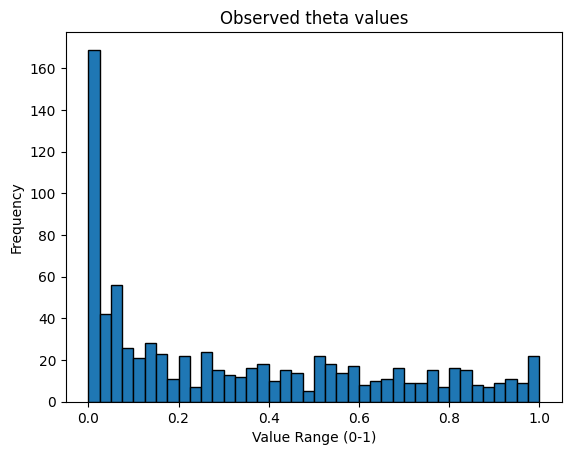

True parameters: [62.5, -134.16666666666666, 96.99999999999999, -27.625]
Fitted parameters: [ 43.36783834 -97.99254828  75.55467865 -23.46221528]


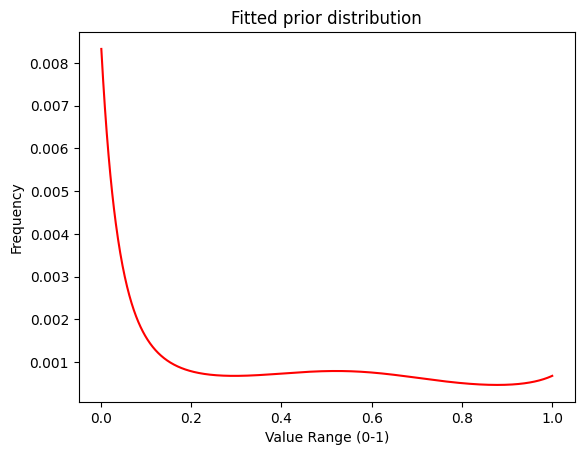

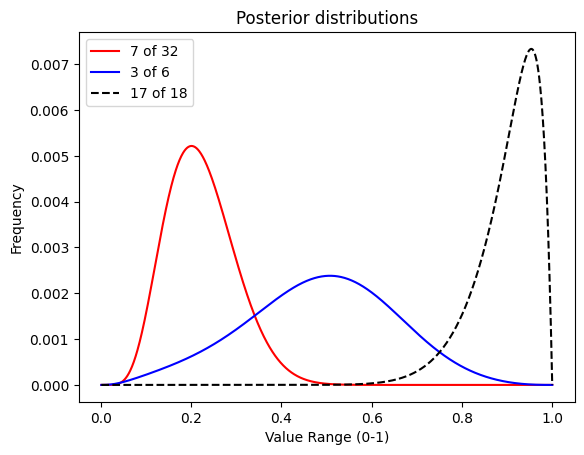

In [ ]:
# @title Empirical prior for lymph nodes {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm
from scipy.special import comb
from scipy.optimize import minimize

def TruePriorDistribution( ):

    Nres = 1000;

    theta = np.linspace(1,Nres,Nres) / Nres;

    a = 0.26;
    b = 0.50;
    c = 0.85;

    S = 250;

    A = S/4; B = -S*(a+b+c)/3; C = S*(a*b+b*c+a*c)/2; D = -S*a*b*c;

    LPtheta = A * theta**4 + B * theta**3 + C * theta**2 + D * theta;

    # collect parameters
    alpha = [A, B, C, D];

    # exponentiate
    Ftheta = np.exp( LPtheta );

    # normalize

    Ftheta = Ftheta / np.sum(Ftheta)

    Ctheta = np.cumsum(Ftheta)

    return alpha, theta, Ftheta, Ctheta


def GetPriorDistribution( theta, alpha):

    A = alpha[0];
    B = alpha[1];
    C = alpha[2];
    D = alpha[3];

    LPtheta = A * theta**4 + B * theta**3 + C * theta**2 + D * theta;

    # exponentiate
    Ftheta = np.exp( LPtheta );

    # normalize
    Ftheta = Ftheta / np.sum(Ftheta)

    return Ftheta


def SamplePriorDistribution( Npatient ):

    (alpha, theta, Ftheta, Ctheta) = TruePriorDistribution()

    theta_k = np.zeros(Npatient)

    #print( Ctheta )

    for k in range(Npatient):

        idx = np.where( k/Npatient <= Ctheta )[0]

        #print( k/Npatient, theta[ idx[0]], Ctheta[ idx[0]])

        theta_k[k] = theta[ idx[0] ];

    return theta_k, alpha

def NegativeLogLikelihood(alpha, positive_k, node_k):

    Nres = 1000;
    theta = np.linspace(1,Nres,Nres) / Nres;
    Ftheta = GetPriorDistribution( theta, alpha)

    Npatient = len(positive_k)

    fmarginal_k = np.zeros(Npatient)

    p_k = positive_k / node_k;

    for k in range(Npatient):

        theta_contribution = comb(node_k[k], positive_k[k]) * theta**(positive_k[k]) * (1-theta)**(node_k[k]-positive_k[k])

        fmarginal_k[k] = np.sum( theta_contribution * Ftheta )

    NLL = -np.sum( np.log( fmarginal_k ) )

    return NLL


def GetPosteriorDistribution(theta, alpha, positive, node):

    Gtheta = GetPriorDistribution( theta, alpha)

    Ptheta = comb(node, positive) * theta**(positive) * (1-theta)**(node-positive)

    PPost = Ptheta * Gtheta / np.sum( Ptheta * Gtheta )

    return PPost



# start the main programm, by generating the observations
# for each patient k, get the number of nodes, the number
# of positive ones, and the fraction

Npatient = 800;

(theta_k, true_alpha) = SamplePriorDistribution( Npatient )

node_k  = np.random.binomial(n=100, p=0.2, size=Npatient)

positive_k  = np.random.binomial(n=node_k, p=theta_k)

fraction_k = positive_k / node_k



# plot the population data
plt.hist(fraction_k, bins=40, edgecolor='black')

# Adding labels for clarity
plt.title('Observed theta values')
plt.xlabel('Value Range (0-1)')
plt.ylabel('Frequency')

plt.show()


# now try to maximize the likelihood of the prior distribution
# given our observations node_k and positive_k, as well as an
# initial guess for alpha, we want to iteratively find the alpha
# that maximizes the log likelihood of our observations


# 2. Provide an initial guess (required for multivariate optimization)
initial_guess = [50, -100, 100, -25]

# 3. Call minimize
# method='Nelder-Mead' is a robust choice for functions without known derivatives
result = minimize(
    NegativeLogLikelihood,
    initial_guess,
    method='Nelder-Mead',
    args = (positive_k, node_k)
)

# 4. Extract results
if result.success:
    fitted_alpha = result.x
    print(f"True parameters: {true_alpha}")
    print(f"Fitted parameters: {fitted_alpha}")
else:
    print("Optimization failed:", result.message)


# Get fitted prior distribution

Nres = 1000;
theta = np.linspace(1,Nres,Nres) / Nres;
Ftheta = GetPriorDistribution( theta, fitted_alpha)

# plot the empirical prior
plt.plot(theta, Ftheta, 'red')

# Adding labels for clarity
plt.title('Fitted prior distribution')
plt.xlabel('Value Range (0-1)')
plt.ylabel('Frequency')

plt.show()



# get posterior distributions for three patients


x_1 = 7
n_1 = 32

x_2 = 3
n_2 = 6

x_3 = 17
n_3 = 18

alpha = fitted_alpha

positive = np.array([x_1, x_2, x_3])
node = np.array([n_1, n_2, n_3])


Ppost1 = GetPosteriorDistribution(theta, fitted_alpha, x_1, n_1 );

Ppost2 = GetPosteriorDistribution(theta, fitted_alpha, x_2, n_2 );

Ppost3 = GetPosteriorDistribution(theta, fitted_alpha, x_3, n_3 );

# plot the posteriors
plt.plot(theta, Ppost1, 'r', label='7 of 32')
plt.plot(theta, Ppost2, 'b', label='3 of 6')
plt.plot(theta, Ppost3, 'k--', label='17 of 18')
plt.legend()

# Adding labels for clarity
plt.title('Posterior distributions')
plt.xlabel('Value Range (0-1)')
plt.ylabel('Frequency')

plt.show()













# Probability of alien life (optional)

Let $p$ be the prior probability that a star system is inhabited by a alien life (intelligent or otherwise). If we survey $N$ star systems (including our own), the binomial probability of observing exactly $n$ inhabited systems is

$$
P_n(p,N) = \binom{N}{n}\, p^n \, (1-p)^{N-n}
$$

The conditional probability of two or more inhabited system, given that there already exists one such system (our own) is

$$
P_\mathit{alien}(p,N) = \frac{1 - P_0(p,N) - P_1(p,N)}{1 - P_0(p,N)}
$$

<br>

A conservative estimate for the prior probability is $p=\frac{1}{N}$, since our own system exists. Accordingly, we can estimate the probability of alien life, as a function of $N$, as follows

$$
P_\mathit{alien}(N) = \frac{1 - P_0(1/N,N) - P_1(1/N,N)}{1 - P_0(1/N,N)}
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_finding_aliens.png" width="600">

<br>

This calculation shows that the probability of finding alien life asymptotes at 42% as the number of surveyed solar systems increases.  Douglas Adams knew this all along.

<br>

**Cautionary note:** due to our limited knowledge, we assign the same prior probability to microbial life, multicellular macroscopic life, and sentient life. Surely these will turn out to be vastly different!

# **3. Bayesian Information Criterion (BIC)**

To motivate this approach, let's first return to the concept of a **Bayes Factor**.

<br>

Consider an independent normal sample

$$
{\bf x} = (x_1, x_2, \ldots , x_n), \qquad\qquad x_i\sim \mathscr{N}(\mu,1)
$$

and the problem of distingushing between two hypotheses or 'models'.

$$
\mathscr{M}_0: \mu=0, \qquad\qquad \mathscr{M}_1: \mu\neq 0
$$

<br>

Assume that we know the prior probabilities of both models

$$
\mathrm{Pr}\left(\mathscr{M}_0\right) = \pi_0, \qquad\qquad \mathrm{Pr}\left(\mathscr{M}_1\right) =\pi_1 = 1 - \pi_0
$$

as well as the conditional prior densities of $\mu$ under both models

$$
g_0(\mu) = g\left(\mu | \mathscr{M}_0 \right), \qquad\qquad g_1(\mu) = g\left(\mu | \mathscr{M}_1 \right)
$$

If $f_\mu({\bf x})$ is the density of $\bf x$ given $\mu$, the marginal distributions of ${\bf x}$, over the two families of models, follow as

$$
f_0({\bf x}) = \int f_\mu({\bf x}) \, g_0({\bf \mu}) \, d{\bf \mu},\qquad\qquad f_1({\bf x}) = \int f_\mu({\bf x}) \, g_1({\bf \mu}) \, d{\bf \mu}
$$

<br>

From Bayes' theorem, we can now obtain the posterior probability ratio of models, given our observations ${\bf x}$,

$$
\frac{\pi_1({\bf x})}{\pi_0({\bf x})} \quad= \quad \frac{f_1({\bf x})}{f_0({\bf x})} \cdot \frac{\pi_1}{\pi_0}
$$

<br>

as the product of the Bayes factor $BF({\bf x}) = \frac{f_1({\bf x})}{f_0({\bf x})}$ and the prior probability ratio $\frac{\pi_1}{\pi_0}$

<br>

**The BIC is a heuristic method for calculating Bayes factors.**






/tmp/ipykernel_2741/622433841.py:89: RuntimeWarning: divide by zero encountered in log
  axs[1,1].plot(np.log(counts1)-np.log(counts0), 'b-', lw=2.5, label='log BF')


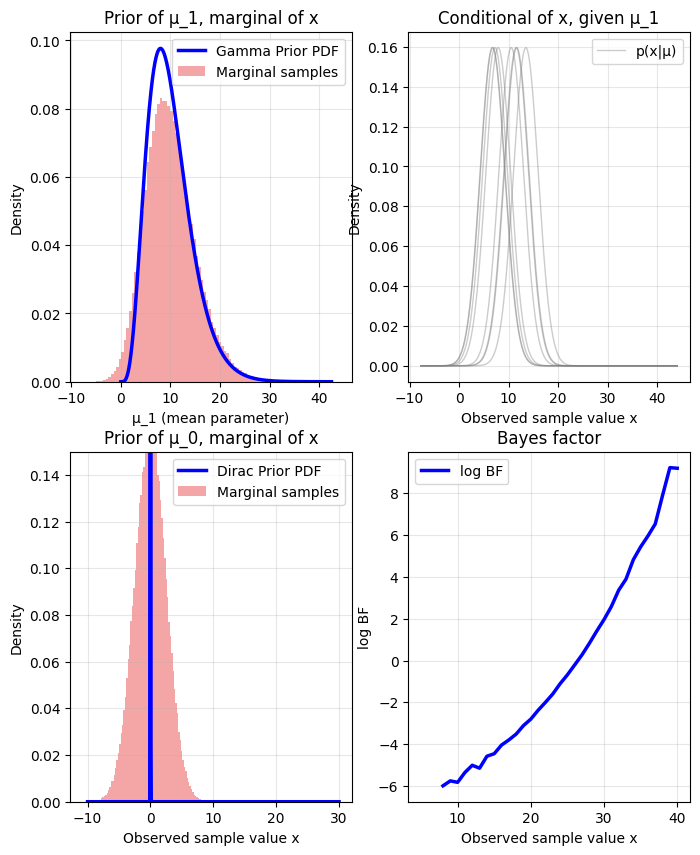

In [ ]:
# @title Prior, marginal, and conditional distributions, for Model 1 {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
# Prior: mu ~ Gamma(shape=alpha, scale=theta)  [mean = alpha * theta]
alpha = 5.0      # shape parameter
theta = 2.0      # scale parameter (mean mu = 10.0)
# Alternatively: rate = 1/theta = 0.5

# Likelihood: X | mu ~ Normal(mu, sigma)
sigma = 2.5

# Number of simulations
n_mus = 5000          # number of mu samples from prior
n_samples_per_mu = 50 # samples per mu for marginal approximation

# Generate mu from prior
mus = gamma.rvs(a=alpha, scale=theta, size=n_mus)

# Generate samples from the marginal distribution
# (by first sampling mu, then sampling x|mu)
samples1 = np.zeros(n_mus * n_samples_per_mu)
idx = 0
for mu in mus:
    samples1[idx:idx + n_samples_per_mu] = norm.rvs(loc=mu, scale=sigma, size=n_samples_per_mu)
    idx += n_samples_per_mu

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(8, 10))

# Plot 1: Prior distribution of mu
x_mu = np.linspace(0, max(30, mus.max() * 1.1), 1000)
prior_pdf = gamma.pdf(x_mu, a=alpha, scale=theta)

# Plot 2: Marginal distribution of samples
x_range = np.linspace(samples1.min(), samples1.max(), 1000)


axs[0,0].plot(x_mu, prior_pdf, 'b-', lw=2.5, label='Gamma Prior PDF')
#axs[0].hist(mus, bins=80, density=True, alpha=0.6, color='skyblue', label='Sampled μ values')
axs[0,0].hist(samples1, bins=100, density=True, alpha=0.7, color='lightcoral', label='Marginal samples')
axs[0,0].set_title('Prior of μ_1, marginal of x')
axs[0,0].set_xlabel('μ_1 (mean parameter)')
axs[0,0].set_ylabel('Density')
axs[0,0].legend()
axs[0,0].grid(True, alpha=0.3)

# Note: true marginal is a bit complex (not a standard distribution), so histogram is the practical way

for i in range(0, len(mus), len(mus)//8):  # show a few representative conditionals
    axs[0,1].plot(x_range, norm.pdf(x_range, loc=mus[i], scale=sigma),
             alpha=0.4, lw=1, color='gray', label='p(x|μ)' if i==0 else "")
axs[0,1].set_title('Conditional of x, given μ_1')
axs[0,1].set_xlabel('Observed sample value x')
axs[0,1].set_ylabel('Density')
axs[0,1].legend()
axs[0,1].grid(True, alpha=0.3)


samples0 = norm.rvs(loc=0, scale=sigma, size=n_mus*n_samples_per_mu)

x_mu0 = np.linspace(-10, 30, 1000)
null_pdf = norm.pdf(x_mu0, loc=0.0, scale=sigma/100)

axs[1,0].plot(x_mu0, null_pdf, 'b-', lw=2.5, label='Dirac Prior PDF')
#axs[0].hist(mus, bins=80, density=True, alpha=0.6, color='skyblue', label='Sampled μ values')
axs[1,0].hist(samples0, bins=100, density=True, alpha=0.7, color='lightcoral', label='Marginal samples')
axs[1,0].set_title('Prior of μ_0, marginal of x')
axs[1,0].set_ylim([0,0.15])
axs[1,0].set_xlabel('Observed sample value x')
axs[1,0].set_ylabel('Density')
axs[1,0].legend()
axs[1,0].grid(True, alpha=0.3)


# 1. Define common bin edges
common_bins = np.histogram_bin_edges(np.concatenate([samples1, samples0]), bins=100)

# 2. Apply those bins to both arrays
counts1, _ = np.histogram(samples1, bins=common_bins)
counts0, _ = np.histogram(samples0, bins=common_bins)

axs[1,1].plot(np.log(counts1)-np.log(counts0), 'b-', lw=2.5, label='log BF')
axs[1,1].set_title('Bayes factor')
axs[1,1].set_xlabel('Observed sample value x')
axs[1,1].set_ylabel('log BF')
axs[1,1].legend()
axs[1,1].grid(True, alpha=0.3)

plt.show()



# Bayesian information criterion (BIC)

The BIC is a **heuristic** that compares quality of model fit and model complexity.  Specifically

<br>

$$
\mathrm{BIC} = -2 \log( \mathscr{\hat L}) + p \log (n)
$$

<br>

where $\mathscr{\hat L} = f_1({\bf x})$ is the likelhood of the observed data ${\bf x}$ under model $\mathscr{M}_1$, $p$ is the number of model parameters, and $n$ is the number of data points.

<br>

A **lower BIC** indicates a **better model**.

<br>


# BIC for normally distributed observations

As the above is a bit abstract, let's consider the simplest possible example. For normally distributed observation errors, the likelihood of observations is

$$
f_1({\bf x}) = \frac{1}{\left(2\pi \, \left\langle\sigma_e^2\right\rangle\right)^{n/2}} \,\, \exp\left(-\frac{1}{2\left\langle\sigma_e^2\right\rangle}\sum_{i=1}^n \left(x_i-\mu\right)^2\right)
$$

If we estimate error variance from the **residual sum of squares, RSS**

$$
\left\langle\sigma_e^2\right\rangle = \frac{1}{n} \sum_{i=1}^n(x_i - \mu)^2
$$

this simplifies to

$$
f_1({\bf x}) = \frac{1}{\left(2\pi \, \left\langle\sigma_e^2\right\rangle\right)^{n/2}} \,\, \exp\left(-\frac{n}{2\left\langle\sigma_e^2\right\rangle}\left\langle\sigma_e^2\right\rangle^2\right)
$$

and the log likelihood becomes

$$\begin{eqnarray}
\log f_1({\bf x}) &=& -\frac{n}{2} \log (2\pi) - \frac{n}{2} \log  \left\langle\sigma_e^2\right\rangle - \frac{n }{2}
=
\\
&=& -\frac{n}{2} \left[\log\left\langle\sigma_e^2\right\rangle + \log (2\pi) + 1\right] \approx
\\
&\approx& -\frac{n}{2} \log \left\langle\sigma_e^2\right\rangle  
\end{eqnarray} $$

<br>

The constant terms $\log(2\pi) + 1$ can be ignored for purposes of model comparison.

<br>

Accordingly, the BIC for normally distributed observations becomes

$$\begin{eqnarray}
BIC &=& - 2 \log f_1({\bf x}) + p \log n \approx
\\
\\
&\approx&  n \log \left\langle\sigma_e^2\right\rangle +  p \log n
\end{eqnarray}$$


<br>

Note that the BIC increases both with the estimated square error and with the number of model parameters. The number of data points enters into both terms.

<br>

Once again, the BIC is a **heuristic** expression, not a principled one!


In [ ]:
from inspect import signature
# @title BIC with normally distributed observations {"vertical-output":true,"display-mode":"form"}
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from scipy.stats import poisson
from scipy.stats import norm
from scipy.stats import binom
from scipy.optimize import curve_fit


def plot_BIC_with_normal_data(n = 20, sigma_e=2):

    # Regression data
    x = np.arange(1, n).reshape(-1, 1)
    y = 0.2 * (x - 5)**2 + 2 * x + np.random.normal(0, sigma_e, size=x.shape)

    n = len(x)

    # --- Model M1: Linear (intercept + x) ---
    X1 = np.hstack((np.ones_like(x), x))  # Design matrix with intercept
    b1 = np.linalg.lstsq(X1, y, rcond=None)[0]  # Least squares fit

    y1 = X1 @ b1  # Prediction
    varerr1 = np.mean((y - y1)**2)

    p1 = 3  # 2 model params + sigma
    BIC1 = n * np.log(varerr1) + p1 * np.log(n)

    # --- Model M2: Quadratic (intercept + x + x^2) ---
    X2 = np.hstack((np.ones_like(x), x, x**2))  # Add x^2 term
    b2 = np.linalg.lstsq(X2, y, rcond=None)[0]

    y2 = X2 @ b2  # Prediction
    varerr2 = np.mean((y - y2)**2)

    p2 = 4  # 3 model params + sigma
    BIC2 = n * np.log(varerr2) + p2 * np.log(n)

    # Bayes factor model 2 versus model 1
    BF = np.exp(BIC1 - BIC2)

    BFalt = ( varerr1**n * n**p1 ) / ( varerr2**n * n**p2 )

    print(" Bayes factor:", BF)

    # --- Plot ---
    xx = np.linspace(0, n, 100).reshape(-1, 1)
    yy1 = b1[0] + b1[1]*xx
    yy2 = b2[0] + b2[1]*xx + b2[2]*xx**2

    plt.figure(figsize=(12, 6))
    plt.plot(x, y, 'ko', label='Data')
    plt.plot(xx, yy1, 'b-', linewidth=2, label='Linear model')
    plt.plot(xx, yy2, 'r-', linewidth=2, label='Quadratic model')
    plt.gca().set_aspect(4/n, adjustable='box')
    plt.legend()
    plt.title(f'BIC Model 1: {BIC1:.2f} BIC Model 2: {BIC2:.2f}')
    plt.xlabel('x')
    plt.ylabel('y')

    plt.tight_layout()
    plt.show()

# Creating sliders for concentrations and charge
interact(plot_BIC_with_normal_data, n = (10,100,10), sigma_e = (1, 10, 1 )  )


interactive(children=(IntSlider(value=20, description='n', min=10, step=10), IntSlider(value=2, description='s…

<function __main__.plot_BIC_with_normal_data(n=20, sigma_e=2)>

# Bayes factor and BIC

The BIC lets us compare models in terms of a Bayes factor $BF_\mathrm{BIC}$, if we assume

<br>

$$
P(\mathscr{M}_1|{\bf x}) = e^{-BIC(\mathscr{M}_1)}, \qquad\qquad P(\mathscr{M}_0|{\bf x})= e^{-BIC(\mathscr{M}_0)}
$$

<br>

$$
BF_\mathrm{BIC}({\bf x}) =\frac{P(\mathscr{M}_1|{\bf x})}{P(\mathscr{M}_0|{\bf x})}= \exp\left[ \mathrm{BIC}(\mathscr{M}_0) - \mathrm{BIC}(\mathscr{M}_1)\right] = \left[\frac{f_1({\bf x})}{f_0({\bf x})}\right]^2 \cdot \frac{n^{p_0}}{n^{p_1}}
$$

<br>

$$
\log BF_\mathrm{BIC}({\bf x}) = \mathrm{BIC}(\mathscr{M}_0) - \mathrm{BIC}(\mathscr{M}_1) = - 2 \log\frac{f_0({\bf x})}{f_1({\bf x})} + \log \frac{n^{p_0}}{n^{p_1}}
$$



<br>

that describes how our observations $\bf x$ change the odds in favour of one model or another.

<br>

In the coded toy example above, the BIC of Linear Model 1 is $\sim 80$, whereas that of Quadratic Model 2 is $\sim 30$, so that the odds change by a factor of $10^{18}$ in favour of Model 2:

$$
B_\mathrm{BIC} \approx e^{-30+80} \approx 10^{18}
$$

# BIC with Poisson distributed observations

For Poisson distributed observations $\bf y$ with expectation $\boldsymbol\mu=\langle {\bf y}\rangle$, the natural parameter is $\boldsymbol\lambda = \log \boldsymbol\mu$, which we fit as

$$
\boldsymbol\lambda (\boldsymbol \alpha) = \log \boldsymbol\mu(\boldsymbol \alpha) = {\bf X} \cdot \boldsymbol \alpha
$$

<br>

The Poisson distribution is

$$
f_{\mu}(y) = \frac{\mu^y \, e^{-\mu}}{y!}, \qquad\qquad \log f_{\mu}(y) = y\log \mu - \mu - y \log y + y = y\lambda - e^\lambda - y \log y + y
$$

so that the (parameter-dependent part of the) log likelihood of observations given model predictions $\boldsymbol\mu(\boldsymbol \alpha)$ is

$$
\log f_{\boldsymbol\mu}({\bf y}) = \sum_i \log f_{\mu_i}(y_i) = \sum_i \left[ y_i \log \mu_i - \mu_i\right]= \sum_i \left[ y_i \lambda_i - e^{\lambda_i}\right]
$$


<br>

Let's illustrate this the Galaxy count example from the previous lecture.

Recall that we fitted the expected number of Galaxies with redshift $r$ and magnitude $m$ with a quadratic polynomial

$$
\mathscr{M}_2:  \qquad \lambda(r,m) = \alpha_1 r + \alpha_2 m + \alpha_3 r^2 + \alpha_4 r m + \alpha_5 m^2
$$

<br>

Now we want to compare two further models, which are missing one or both of the square terms:

$$
\mathscr{M}_1:  \qquad \lambda(r,m) = \alpha_1 r + \alpha_2 m + \alpha_3 r^2 + \alpha_4 r m
$$

$$
\mathscr{M}_0:  \qquad \lambda(r,m) = \alpha_1 r + \alpha_2 m + \alpha_3 r m
$$

<br>

Given these models, we can compute the Bayes factors from the probability of observations, given each model


$$
BIC_2 = - 2 \log f_2({\bf y})+ p_2 \log (n), \qquad\qquad p_2=5, n= 270
$$

$$
BIC_1 = - 2 \log f_1({\bf y})+ p_1 \log (n), \qquad\qquad p_1=4, n= 270
$$

$$
BIC_0 = - 2 \log f_0({\bf y})+ p_0 \log (n), \qquad\qquad p_0=3, n= 270
$$

where $p$ is the number of parameters in each model and $n$ is the number of observation bins.

<br>

The Bayes factor between two models $\mathscr{M}_1$ and $\mathscr{M}_2$ is

$$
\frac{P(\mathscr{M}_1|{\bf x})}{P(\mathscr{M}_2|{\bf x})}= \exp\left[ \mathrm{BIC}(\mathscr{M}_2) - \mathrm{BIC}(\mathscr{M}_1)\right] = \left[\frac{f_1({\bf x})}{f_2({\bf x})}\right]^2 \cdot \frac{n^{p_2}}{n^{p_1}}
$$




Model Log Likelihood BIC
M0 -257.04246159415936 532.0593168296426
M1 -148.25413722028281 320.47413262899755
M2 -136.26911600721814 302.4955547499762


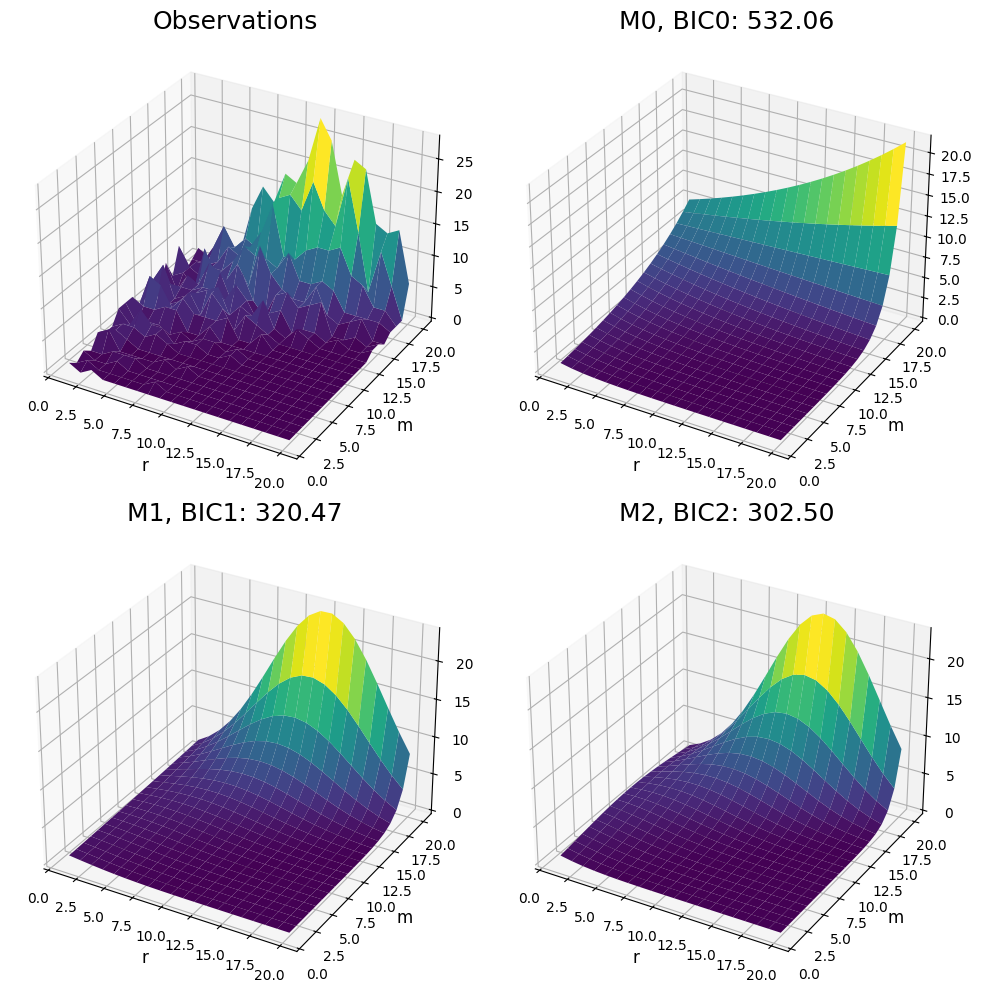

In [ ]:
# @title BIC example for Poisson regression {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import statsmodels.api as sm


# Define negative log-likelihood for Poisson distribution
def NegativeLogLikelihood(alpha, X, y):
    alpha = np.array(alpha)
    alpha = alpha.reshape(-1,1)
    natparam = X @ alpha
    log_likelihood = y * natparam - np.exp(natparam)
    return -np.sum(log_likelihood)

# Define BIC for Poisson distribution
def BayesianInformationContent(alpha, X, y):
    alpha = np.array(alpha)
    alpha = alpha.reshape(-1,1)
    natparam = X @ alpha

    log_likelihood = y * natparam - np.exp(natparam)

    ix = np.where(y>0)
    logyfaci = y[ix] * np.log(y[ix]) - y[ix]

    LL  = np.sum(log_likelihood) - np.sum(logyfaci)

    BIC = -2 * LL + len(alpha) * np.log( len(y) )

    return LL, BIC

# define data support
Nr = 20;
Nm = 20;

rrange = np.arange(1,Nr+1)
mrange = np.arange(Nm,0,-1)

rarray = np.tile( rrange, (Nr, 1) )
marray = np.tile( mrange, (Nm, 1) ).T

# define bivariate distribution of natural parameter

alpha_true = np.array([-0.34783406,  0.14192231, -0.0223069,   0.04640992, -0.00861051]);
alpha_true = alpha_true.reshape(-1,1)

# flatten arrays

r = rarray.reshape(-1,1)
m = marray.reshape(-1,1)

# design matrix

X_true = np.hstack((r, m, r**2, r*m, m**2))

# generate observations
lambda_true = X_true @ alpha_true
mu_true  = np.exp(lambda_true)

y = np.random.poisson(mu_true)

yarray = y.reshape(Nm,Nr)


# Design matrix of model 2

X_M2 = np.hstack((r, m, r**2, r*m, m**2))

# Fit GLM with Poisson distribution, using STATSMODELS
# model = sm.GLM(y, X_M2, family=sm.families.Poisson(sm.families.links.Log()))
# results = model.fit()
# alpha_M2 = results.params

# Fit model by hand, results should be identical
alpha_initial = [-0.2,  0.1, 0.0, 0.0, 0.0];
result = minimize(
    NegativeLogLikelihood,
    alpha_initial,
    method='Nelder-Mead',
    args = (X_M2, y)
)
alpha_M2 = result.x

# Predicted observations
lambda_M2 = X_M2 @ alpha_M2
mu_M2  = np.exp(lambda_M2)

mu_M2_array = mu_M2.reshape(Nm,Nr)

# Design matrix of model 1

X_M1 = np.hstack((r, m, r**2, r*m))

# Fit GLM with Poisson distribution, using STATSMODELS
# model = sm.GLM(y, X_M1, family=sm.families.Poisson(sm.families.links.Log()))
# results = model.fit()
# alpha_M1 = results.params

# Fit model by hand, results should be identical
alpha_initial = [-0.2,  0.1, 0.0, 0.0];
result = minimize(
    NegativeLogLikelihood,
    alpha_initial,
    method='Nelder-Mead',
    args = (X_M1, y)
)
alpha_M1 = result.x

# Predicted observations
lambda_M1 = X_M1 @ alpha_M1
mu_M1  = np.exp(lambda_M1)

mu_M1_array = mu_M1.reshape(Nm,Nr)

# Design matrix of model 0

X_M0 = np.hstack((r, m, r*m))

# Fit GLM with Poisson distribution, using STATSMODELS
# model = sm.GLM(y, X_M0, family=sm.families.Poisson(sm.families.links.Log()))
# results = model.fit()
# alpha_M0 = results.params

# Fit model by hand, results should be identical
alpha_initial = [-0.2,  0.1, 0.0];
result = minimize(
    NegativeLogLikelihood,
    alpha_initial,
    method='Nelder-Mead',
    args = (X_M0, y)
)
alpha_M0 = result.x


# Predicted observations
lambda_M0 = X_M0 @ alpha_M0
mu_M0  = np.exp(lambda_M0)

mu_M0_array = mu_M0.reshape(Nm,Nr)


# compute BICs

(LL_M0, BIC_M0) = BayesianInformationContent(alpha_M0, X_M0, y)
(LL_M1, BIC_M1) = BayesianInformationContent(alpha_M1, X_M1, y)
(LL_M2, BIC_M2) = BayesianInformationContent(alpha_M2, X_M2, y)

print( 'Model', 'LogLikelihood', 'BIC')
print( 'M0', LL_M0, BIC_M0 )
print( 'M1', LL_M1, BIC_M1 )
print( 'M2', LL_M2, BIC_M2 )

Delta_BIC_10 = BIC_M0 - BIC_M1
Delta_BIC_21 = BIC_M1 - BIC_M2

# Visualize results
fig = plt.figure(figsize=(10, 10))

# Plot 1: Original counts
ax0 = fig.add_subplot(221, projection='3d')

ax0.plot_surface(rarray, marray, yarray, cmap='viridis')  # You can change colormap

ax0.set_xlabel('r', fontsize=12)
ax0.set_ylabel('m', fontsize=12)
ax0.set_title('Observations', fontsize=18)

# Plot 2: Model 0
ax1 = fig.add_subplot(222, projection='3d')

ax1.plot_surface(rarray, marray, mu_M0_array, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title(f'M0, BIC0: {BIC_M0:.2f}', fontsize=18 )

# Plot 2: Model 1
ax1 = fig.add_subplot(223, projection='3d')

ax1.plot_surface(rarray, marray, mu_M1_array, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title(f'M1, BIC1: {BIC_M1:.2f}', fontsize=18 )

# Plot 2: Model 2
ax1 = fig.add_subplot(224, projection='3d')

ax1.plot_surface(rarray, marray, mu_M2_array, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title(f'M2, BIC2: {BIC_M2:.2f}', fontsize=18 )

plt.tight_layout()
plt.show()


# **4. False discovery corrections**

Many modern techniques with large-scale testing pose the statistical problem of false (accidental) positives. Performing 100 separate tests at significance level $\alpha=0.05$, will **falsely discover** approximately five "significant" purely by chance.

Efron & Hastie (Chapter 15) present an example from a **prostate cancer** study with microarrays, involving 102 men, 52 prostate cancer patients and 50 normal controls. For each man, expression levels were measured for 6033 genes, yielding a $6033 \times 102$ matrix of observations $x_{ij}$, with $i$ indexing genes and $j$ indexing men.

For each gene, a two-sample statistic compared expression levels patient and control groups. Under the null hypothesis H0 that expression levels come from the same normal distribution, the $t_i$ for gene $i$ will follow a standard Student t distribution with $100$ degrees of freedom, $t_{100}$. Transformation with the CDF of $t_{100}$ and the inverse normal PDF produces standard normally distributed observations, $z_i$, under the null hypothesis:

$$
z_i = \Phi^{-1}\left[F_{100}(t_i) \right]
$$

The illustration below compares the observed distribution (histogram) with the null hypothesis (red curve), a standard normal distribution, scaled to counts:

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_prostate_cancer_genes.png" width="600">

<br>

**So the question is, are some genes significantly over- or under-expressed?**


# Bonferroni correction

The classical Bonferroni correction lowers the threshold of significance from $\alpha$ for an individual test to $\alpha/N$ for $N$ simultaneous tests. In other words, the null hypothesis is rejected only when the $p$-value of some test is $p<\alpha/N$.

<br>

In the case of the prostate cancer study, with $N=6033$, the Bonferroni-corrected threshold for significance would be

$$
\alpha_\mathit{corr} = \frac{\alpha}{N} = \frac{0.05}{6033} = 8.3\times 10^{-6}
$$

This standard of evidence is quite stringent and only four genes in the cancer study pass this test.


# Benjamini-Hochberg correction

The current standard is more liberal and was proposed by [Benjamini & Hochberg (1995)](https://academic.oup.com/jrsssb/article/57/1/289/7035855?login=false), whose paper has been cited 115,940 times to date!

<br>

Suppose that our statistical decision rule $\mathscr{D}(\alpha)$ yields an **apparent proportion** of $\frac{R}{R+N}$ of  non-null hypotheses, whereas the the **(unknown) true proportion** of non-null hypotheses is $\frac{N_1}{N_0+N_1}$.


<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_FDR_definition.png" width="500">

<br>

If different tests are statistically independent and if true discoveries are rare, we can approximate the  **false-discovery rate (FDR)** with the overall **overall discovery rate (ODR)**:

$$
\mathrm{FDR}[\mathscr{D}(\alpha)] = \frac{a}{R} \approx \frac{N_0}{N_0+N_1}= \mathrm{ODR}[\mathscr{D}(\alpha)]
$$



<br>

To clarify, suppose we have observed $N$ z-score values $z_i$, where $i\in\{1, \ldots, N\}$, and have establish the associated p-values $p_i. Recall that the p-value of a z-score value is an integral over the standard normal distribution

$$
p(z) = \int_{z}^{+\infty} \mathscr{N}(0,1) \, dz
$$

In other words, the p-value $p_i$ is the proportion of z-values **larger than** or equal to $z_i$ or, equivalently, the proportion of p-values **smaller than** or equal to $p_i$.

<br>

Here now comes the parlour trick!

<br>

Consider $N$ observations $z_i$ that come **exclusively from null hypothesis** and order the associated p-values $p_i$ **from the smallest to the largest**. In this situation, we can approximate p-value with the ordering index $i$:

$$
p_i \approx \mathrm{Prob}[ p< p_i] = \mathrm{Prob}[ z> z_i] = \frac{i}{N}
$$

This idea is illustrated by the code below:






In [ ]:
# @title Sorted p-values {"vertical-output":true,"display-mode":"form"}
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from scipy.stats import poisson
from scipy.stats import norm


def cdf_geq_z(z):
    """
    Computes the cumulative probability of observing values larger than or equal to z
    from a standard normal distribution.

    Args:
        z (float): The z-score.

    Returns:
        float: The cumulative probability P(X >= z) for X ~ N(0, 1).
    """
    return norm.sf(z)


def sorted_p_values(n = 1000, alpha=0.05):

    # standard normal samples
    xi = np.random.randn(n)
    ni = range(n)

    # p-values
    pi = cdf_geq_z( xi )

    # sort p-values
    indices = np.argsort(pi)
    pi_sorted = pi[indices]
    xi_sorted = xi[indices]

    # 'significant' p-values
    ixsig = np.where(pi_sorted < alpha)[0]
    # --- Model M1: Linear (intercept + x) ---


    fig = plt.figure(figsize=(12, 6))

    # Subplot 1: order
    plt.subplot(1, 2, 1)

    plt.plot(ni, pi_sorted, 'k.', label='p-val')
    plt.plot(ixsig, pi_sorted[ixsig], 'r.', label='false discoveries')
    plt.plot([1,n],[alpha,alpha],'r-', label=f'alpha')
    plt.legend()
    plt.title('Sorted p-values')
    plt.xlabel('order')
    plt.ylabel('p-value')

    # Subplot 2: fractions
    plt.subplot(1, 2, 2)

    fi = np.float64(ni)/len(ni)

    plt.plot(fi, pi_sorted, 'k.', label='p-val')
    plt.plot(ixsig/len(ni), pi_sorted[ixsig], 'r.', label='false discoveries')
    plt.plot([0,1],[alpha,alpha],'r-', label=f'alpha')
    plt.legend()
    plt.title('Sorted p-values')
    plt.xlabel('fraction')
    plt.ylabel('p-value')

    #plt.axis('equal')

    plt.tight_layout()
    plt.show()

# Creating sliders for concentrations and charge
interact(sorted_p_values, n = (1000,5000,100), alpha = (0.01,0.05,0.01 )  )


interactive(children=(IntSlider(value=1000, description='n', max=5000, min=1000, step=100), FloatSlider(value=…

<function __main__.sorted_p_values(n=1000, alpha=0.05)>

# Reducing false discoveries

<br>

So false discoverites have p-values

$$
p_i\approx \frac{i}{N} \leq \alpha
$$

<br>

Let's now return to a mixed set of observations, most of which come from the null hypothesis (and would be false discoveries) but some of which come from anon-null hypothesis (and so would be true discoveries).

To reduce the number of false discoveries in this mixed set, we can lower this threshold by some additional factor, $q$, and establish a new criterion

$$
p_i \approx q \frac{i}{N} \leq q \alpha
$$

where conventional choices are $q=0.1$ or $q=0.2$.


<br>

This reduces the probability of false discoveries by factor $q$, ensuring that

$$
\mathrm{FDR} \leq q
$$

<br>

In short, if we are testing very many hypotheses, then we can use the proportion of **overall** non-null hypotheses to restrict the proportion of **false** discoveries, which will hopefully ensure that the majority of our discoveries are **true** .

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_benjamini_hochberg.png" width="600">


<br>

In the cancer study, FDR rejects the null-hypothesis for 28 genes in the right tail of the distribution (over-expression).

# Bayesian motivation for FDR

Benjamini & Hochberg derived their method in a complicated way (Martingale theory, no less!), but it can be easily motivated by a Bayesian argument.

<br>

Assuming that our observations (gene expression levels) reflect a **mixed** population with a large fraction $\pi_0\approx 1$ of expression levels distributed normally about mean zero

$$
f_0(z) \sim \mathscr{N}(0,1)
$$

but a small fraction $\pi_1= 1 - \pi_0$ distributed about some larger mean $\mu_1>0$

$$
f_1(z) \sim \mathscr{N}(\mu_1,1)
$$

the mixed density will be

$$
f_\mathit{mix}(z) = \pi_0 f_0(z) + \pi_1 f_1(z)
$$

and the survivor fraction (probability of values **above** $z_\theta$)  will be

$$
S_\mathit{mix}(z_\theta) = \int_{z_\theta}^\infty f_\mathit{mix}(z) \, dz = \pi_0 S_0(z_\theta) + \pi_1 S_1(z_\theta)
$$

<br>

The **p-value** associated with $z_\theta$ is the probability that values **above** $z_\theta$ are generated by the null hypothesis

$$
p(z_\theta) \equiv Prob_\mathit{null}[z\geq z_\theta] = \pi_0 S_0(z_\theta)
$$

<br>

If we rank our $N$ observed $z_i$ values, where $i$ is the rank **from the largest z-value** value (or, equivalently, from the smallest p-value),
then $S_\mathit{mix}(z_\theta)$ is well approximated by $\frac{i}{N}$ for large $N$:

$$
Prob_\mathit{mix}[z\geq z_\theta] = S_\mathit{mix}(z_\theta) \approx \frac{i}{N}
$$

where $i$ is the index of the **largest** $z_i\leq z_\theta$.

<br>

The FDR is the proportion of null-hypothesis samples among all samples **above** $z_\theta$

$$
\mathrm{FDR}[z_\theta] \equiv \frac{Prob_\mathit{null}[z\geq z_\theta]}{Prob_\mathit{mix}[z\geq z_\theta]} = \frac{\pi_0 \, S_0(z_\theta)}{S_\mathit{mix}(z_\theta)} \approx 1
$$

<br>

If we can tolerate a false discovery rate of $q$, we can impose a corresponding bound

$$
\mathrm{FDR}[z_\theta] = \frac{\pi_0 \, S_0(z_\theta)}{S_\mathit{mix}(z_\theta)} \leq q \qquad \Leftrightarrow \qquad  p(z_\theta) =  \pi_0 S_0(z_\theta) \leq  S_\mathit{mix}(z_\theta) \, q \approx \frac{i}{N} \, q
$$

<br>

In other words, if we accept samples $z_i$ with associated p-values $p(z_i)$ **below** this bound, we ensure an FDR below $q$:

$$
p(z_i) \leq \frac{i}{N}q
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/BenjaminiHochberg.png" width="800">

# Local false discovery rates

Let's apply this Bayesian viewpoint to the tail of our distributions and define a **local false discovery rate** for a small region $\mathscr{Z}_0$ centered on $z_0$

<br>

$$
\mathrm{fdr}(\mathscr{Z}_0) = \mathrm{Pr}\left(\mathrm{null} | z_i \in \mathscr{Z}_0 \right), \qquad\qquad \mathscr{Z}_0 = \left[z_0-\frac{d}{2} , z_0 + \frac{d}{2} \right]
$$

where $z_i$ is the value of the test statistic for case $i$. We also assume that our mixed sample population comprises a proportion $\pi_0\approx 1$ of null-hypothesis samples and a proportion $\pi_0\approx 0$ of non-null-hypothesis samples.

<br>

Comparing the observed number  of $z_i$ in this region, $N(\mathscr{Z}_0)$, to the number expected from a standard normal distribution, $N_0 (\mathscr{Z}_0)$, we can estimate

<br>

$$
\mathrm{fdr}(\mathscr{Z}_0) = \frac{N_0 (\mathscr{Z}_0)}{N(\mathscr{Z}_0) } \approx \frac{N \pi_0 f_0(z_0) d}{N(\mathscr{Z}_0)}
$$

where $f_0(z_0)$ is the standard normal density at $z_0$.

<br>

Typically, these estimates are computed for different window centers $z_0$ an then smoothed by some polynomial fit. Once again, this approach works only when the number of hypothesis tests is quite large.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_local_fdr.png" width="500">


<br>

In our cancer study, 27 genes in the right tail and 25 genes in the left tail passed the threshold $fdr\leq q$ (the conventional threshold of "interesting" or worthy of further study), in the sense that $z_i \geq 3.34$ or $z_i\leq -3.40$.






# **Summary**

**1. Bayes Factor**

**2. Empirical Bayesian reasoning **

**3. Bayesian Information Criterion (BIC)**

**4. False discovery correction**


<br>

# **Following lectures**

**Lecture 8: Bootstrapping examples (Stepan Aleshin)**

**Lecture 9: GLM examples (Stepan Aleshin)**

**Lecture 10: Bootstrapping and shuffling (Jochen Braun)**

**Lecture 11: Linear discriminant analysis (Jochen Braun)**

**Lecture 12: Multivariate LDA (Jochen Braun)**